In [1]:
%load_ext autoreload
%autoreload 2

from src.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH, EXTERNAL_DATA_PATH, SAMPLING_RATE
import numpy as np
import pandas as pd
import pynapple as nap
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.io import loadmat

prj = nap.load_folder(PROCESSED_DATA_PATH.parent)
prj.view

def compute_distance(x1, y1, x2, y2):
    return np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

📂 ucsf
├── 📂 external
├── 📂 interim
├── 📂 processed
│   ├── active_wake.npz         |        IntervalSet
│   ├── angle_openfield.npz     |        Tsd
│   ├── hd_spikes_openfield.npz         |        TsdFrame
│   ├── hd_spikes_total.npz     |        TsGroup
│   ├── position_neck.npz       |        TsdFrame
│   ├── pupil_nrem.npz  |        TsdFrame
│   ├── sleep.npz       |        IntervalSet
│   ├── spikes_shank_1.npz      |        TsGroup
│   ├── spikes_shank_2.npz      |        TsGroup
│   ├── spikes_shank_3.npz      |        TsGroup
│   └── turn_spikes.npz         |        TsGroup
└── 📂 raw

In [2]:
sleep_states = nap.load_file(PROCESSED_DATA_PATH / "sleep.npz")

In [3]:
dfs = []

for i in range(1, 6):

    # Load timestamp and prediction csv files
    ts = loadmat(EXTERNAL_DATA_PATH / f"right0{i}_ts.mat")['Intan_frame_TS']
    preds = pd.read_csv(EXTERNAL_DATA_PATH / f"right0{i}.csv")
    print(f'Missing frames: {len(ts) - len(preds)}')

    if i == 4:
        # session 4 has one extra frame
        # not sure where it comes from, so we drop the last frame
        preds = preds.iloc[:-1]

    # Assign timestamps to frames
    preds['ts'] = ts[preds['frame_idx'].to_numpy()]

    # Compute pupil chords and eyelid distances
    preds['pupil_chord'] = compute_distance(preds['pr.x'], preds['pr.y'], preds['pl.x'], preds['pl.y'])
    preds['eyelid_distance'] = compute_distance(preds['eu.x'], preds['eu.y'], preds['ed.x'], preds['ed.y'])

    # Append relevant data to list
    dfs.append(preds[['frame_idx', 'pupil_chord', 'eyelid_distance', 'ts']])
    del preds

df = pd.concat(dfs).reset_index(drop=True)
df = df.dropna()
df

Missing frames: 0
Missing frames: 1484
Missing frames: 191
Missing frames: 105772
Missing frames: 258065


,frame_idx,pupil_chord,eyelid_distance,ts
3,3,93.615008,117.992759,45.439430
4,4,93.088243,119.033674,45.450534
5,5,93.881738,119.784908,45.461682
6,6,93.857784,120.427799,45.472786
7,7,94.006325,121.178827,45.483840
...,...,...,...,...
6887896,3742066,71.333355,106.679114,80699.121474
6887897,3742067,71.167346,106.531620,80699.132575
6887898,3742068,71.294039,106.673660,80699.143636
6887899,3742069,71.086077,106.545312,80699.154739


In [14]:
pupil_data = nap.TsdFrame(t=df['ts'].to_numpy(), d=df[['frame_idx', 'pupil_chord', 'eyelid_distance']].to_numpy(), columns=['frame_idx', 'pupil_chord', 'eyelid_distance'], time_units='s')
pupil_data

Time (s)           frame_idx    pupil_chord    eyelid_distance
---------------  -----------  -------------  -----------------
45.439430302     3                  93.615             117.993
45.450534037     4                  93.0882            119.034
45.461682449     5                  93.8817            119.785
45.472785708     6                  93.8578            120.428
45.483840032     7                  94.0063            121.179
45.494911717     8                  93.3156            120.485
45.506050146     9                  93.6874            119.64
...
80699.099295733  3.74206e+06        71.2289            106.528
80699.110369779  3.74206e+06        71.2489            106.589
80699.121474338  3.74207e+06        71.3334            106.679
80699.132574591  3.74207e+06        71.1673            106.532
80699.143635579  3.74207e+06        71.294             106.674
80699.154738986  3.74207e+06        71.0861            106.545
80699.165843867  3.74207e+06        71.1479         

In [ ]:
def z_score(series):
    return (series - series.mean()) / series.std()

pupil_data['pupil_chord'] = z_score(pupil_data['pupil_chord'].to_numpy())
pupil_data['eyelid_distance'] = z_score(pupil_data['eyelid_distance'].to_numpy())

In [16]:
pupil_data.save(PROCESSED_DATA_PATH / "pupil_full_normalized.npz")
pupil_data = pupil_data.restrict(sleep_states[sleep_states['state'] == 'nrem'])
pupil_data.save(PROCESSED_DATA_PATH / "pupil_nrem_normalized.npz")

Text(0.5, 1.0, 'Instance Score Distribution')

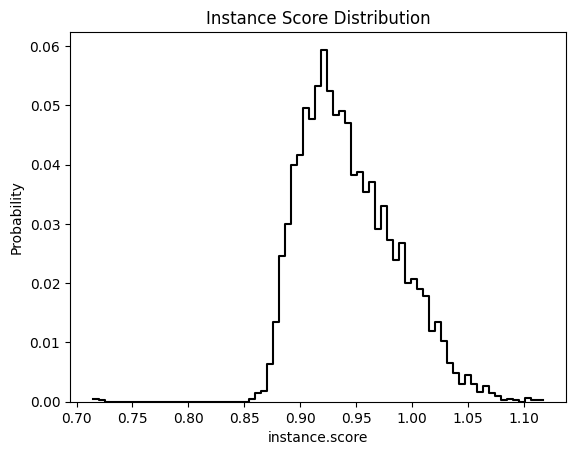

In [9]:
sns.histplot(preds['instance.score'], bins=75, element='step', stat='probability', fill=False, color='k')
plt.title('Instance Score Distribution')

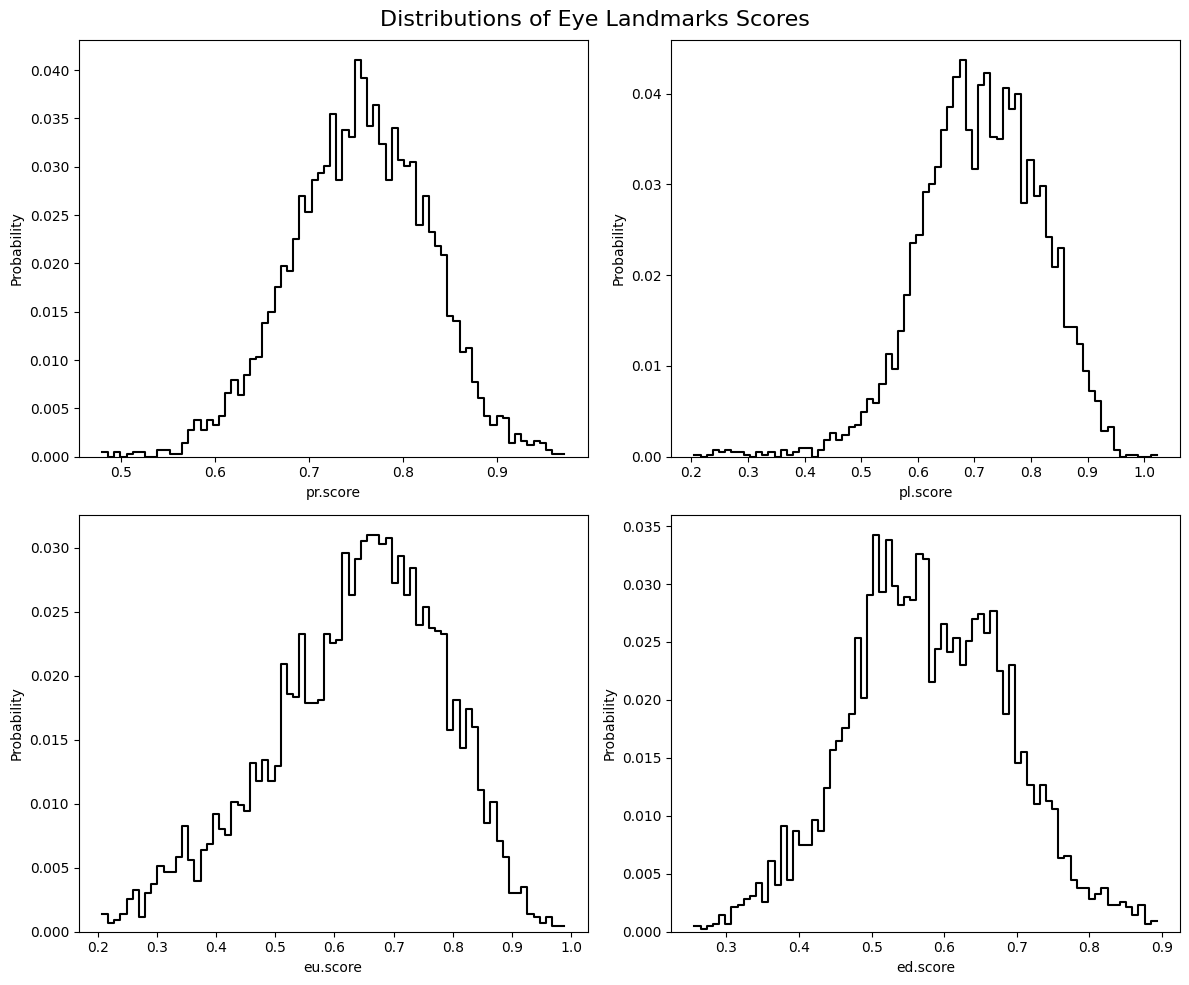

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(['pr', 'pl', 'eu', 'ed']):
    col = col + '.score'
    data = preds[preds[col] >= 0.1]
    sns.histplot(data, x=col, ax=axes[i], bins=75, element='step', stat='probability', fill=False, color='k')

plt.suptitle('Distributions of Eye Landmarks Scores', fontsize=16)
plt.tight_layout()

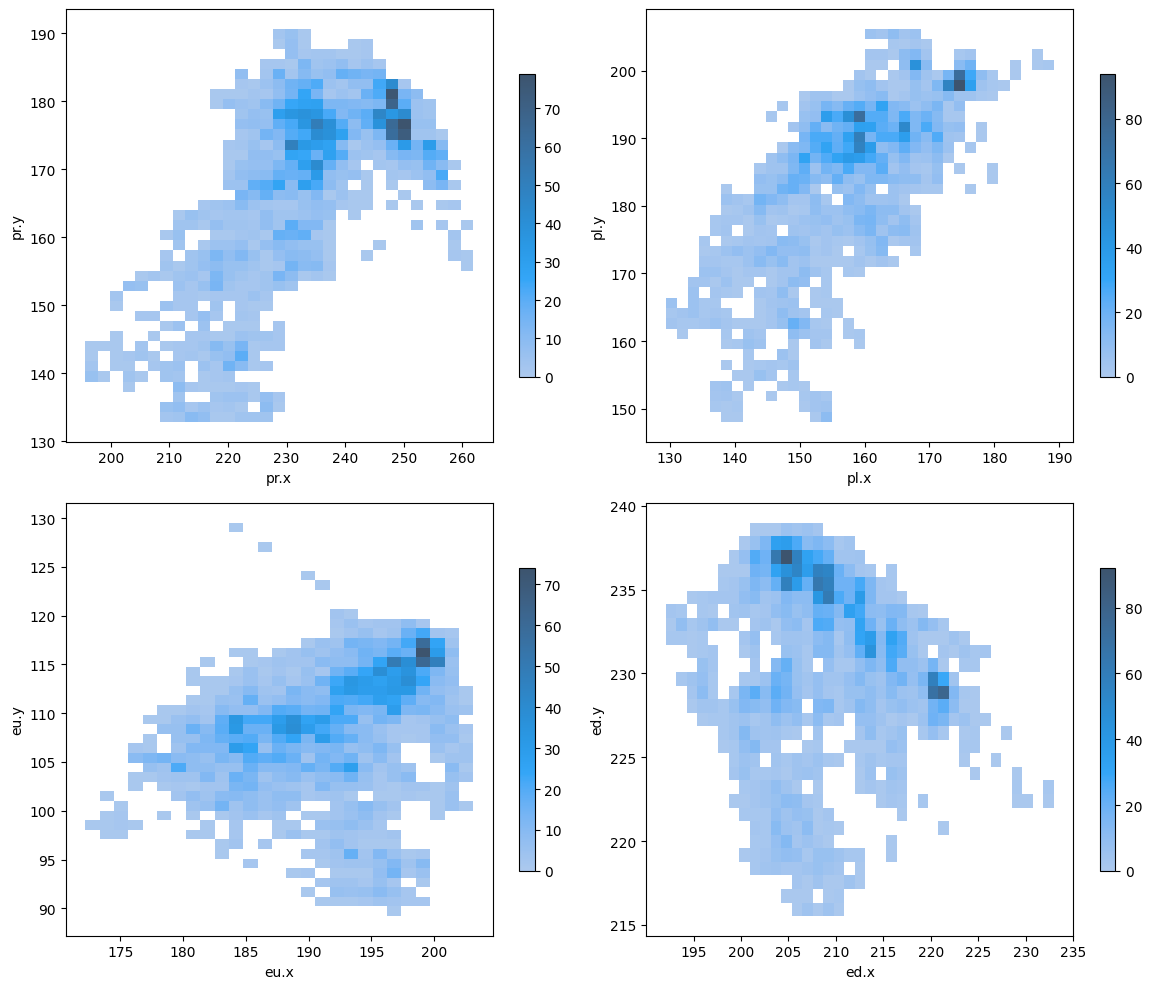

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(['pr', 'pl', 'eu', 'ed']):
    col1 = col + '.x'
    col2 = col + '.y'

    sns.histplot(preds, x=col1, y=col2, ax=axes[i], cbar=True, cbar_kws=dict(shrink=0.7))

plt.tight_layout()

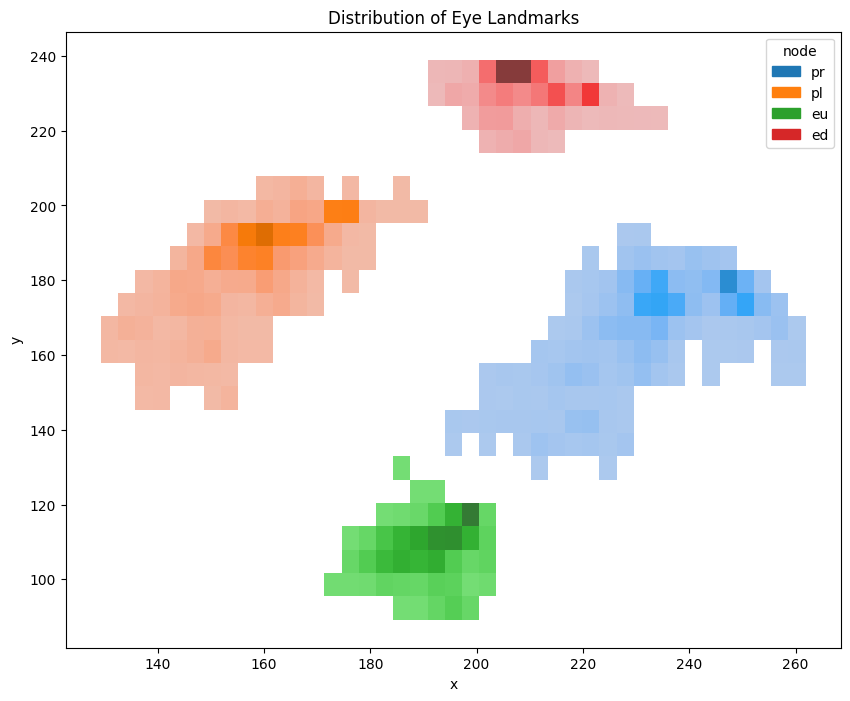

In [19]:
# Plot overlapping 2D histograms (bivariate) for X and Y coordinates
nodes = ['pr', 'pl', 'eu', 'ed']

# Reshape data: Stack x and y coordinates for each node instance into a single dataframe
data_list = []
for node in nodes:
    # Select x and y for the current node
    temp = preds[[f'{node}.x', f'{node}.y']].copy()
    temp.columns = ['x', 'y']
    temp['node'] = node
    data_list.append(temp)

# Concatenate all nodes data
data_2d = pd.concat(data_list, ignore_index=True)

# Plot overlapping 2D histograms
plt.figure(figsize=(10, 8))
sns.histplot(data=data_2d, x='x', y='y', hue='node')
plt.title('Distribution of Eye Landmarks')
plt.show()